# When Do Class-Imbalance Corrections Succeed?

A controlled comparison of **class weighting, random undersampling, SMOTE, and
validation-tuned decision thresholds** across six disease prevalence levels
(2% to 50%), three model families, and ten random seeds, on the full CDC BRFSS
2020 heart disease dataset (319,795 records).

**Headline findings:**
1. Default models fail at low prevalence for every model family (balanced accuracy
   ~0.50 at 2%), and the failure vanishes by 50% prevalence.
2. Which correction works depends on the model: class weighting **fully fails for
   Random Forest at every prevalence** (and can slightly hurt), while working for
   Logistic Regression and Gradient Boosting. **SMOTE fails for both tree
   ensembles** while matching weighting for the linear model.
3. **Validation-tuned thresholding is the only strategy that works for every model
   at every prevalence**, with zero retraining. ROC-AUC is nearly invariant across
   training strategies, which explains why: corrections barely change the learned
   ranking, only the operating point.
4. The selected threshold approximately **equals the prevalence** for
   default-trained models, and reverts to ~0.5 after effective reweighting.

Experimental protocol: 60/20/20 stratified train/validation/test splits; all
thresholds selected on the **validation** split only; metrics reported on the
untouched test split; 1,080 strategy evaluations total.


## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

PREVALENCES = [0.02, 0.05, 0.10, 0.20, 0.35, 0.50]
N_TOTAL = 20000
SEEDS = list(range(10))
CAT = ["Race", "AgeCategory", "GenHealth", "Sex", "Smoking", "AlcoholDrinking",
       "Stroke", "DiffWalking", "Diabetic", "PhysicalActivity", "Asthma",
       "KidneyDisease", "SkinCancer"]
RESULTS_PATH = "results/results.csv"
FORCE_RERUN = False  # set True to re-run the ~15-20 min sweep from scratch

## 2. Data

Full BRFSS 2020 heart disease dataset: 319,795 records, 8.56% positive prevalence.
Controlled-prevalence datasets are built by stratified subsampling: fixed N = 20,000,
with the number of positives set by the target prevalence.


In [2]:
df_full = pd.read_csv("data/heart_2020_cleaned.csv").dropna()
df_full["HeartDisease"] = df_full["HeartDisease"].map({"Yes": 1, "No": 0})
print("Shape:", df_full.shape)
print(f"Positives: {df_full.HeartDisease.sum():,}  ({df_full.HeartDisease.mean():.4f})")

Shape: (319795, 18)
Positives: 27,373  (0.0856)


## 3. Experiment code

In [3]:
def make_dataset(df, prevalence, seed):
    n_pos = int(round(N_TOTAL * prevalence))
    n_neg = N_TOTAL - n_pos
    rng = np.random.RandomState(seed)
    pos, neg = df[df.HeartDisease == 1], df[df.HeartDisease == 0]
    idx = np.concatenate([
        rng.choice(pos.index.values, size=n_pos, replace=False),
        rng.choice(neg.index.values, size=n_neg, replace=False),
    ])
    return df.loc[idx].reset_index(drop=True)

def encode(ds):
    X = ds.drop(columns=["HeartDisease"])
    y = ds["HeartDisease"].values
    Xn = X.drop(columns=CAT)
    Xc = pd.get_dummies(X[CAT], drop_first=True)
    return pd.concat([Xn, Xc], axis=1), y

def metrics_row(y_true, y_pred, proba, thr):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1 = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0
    return dict(TN=tn, FP=fp, FN=fn, TP=tp,
                accuracy=(tp + tn) / len(y_true), sensitivity=sens,
                specificity=spec, balanced_acc=(sens + spec) / 2,
                precision=prec, f1_pos=f1,
                roc_auc=roc_auc_score(y_true, proba),
                pr_auc=average_precision_score(y_true, proba), threshold=thr)

def youden_threshold(y_val, proba_val):
    fpr, tpr, thr = roc_curve(y_val, proba_val)
    return float(thr[np.argmax(tpr - fpr)])

def get_model(name, weighted, seed):
    cw = "balanced" if weighted else None
    if name == "logreg":
        return LogisticRegression(max_iter=2000, class_weight=cw, random_state=seed)
    if name == "rf":
        return RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                      class_weight=cw, random_state=seed)
    if name == "hgb":
        return HistGradientBoostingClassifier(class_weight=cw, random_state=seed)

def run_cell(df, prevalence, seed, out):
    ds = make_dataset(df, prevalence, seed)
    X, y = encode(ds)
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.40,
                                                random_state=seed, stratify=y)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50,
                                                random_state=seed, stratify=y_tmp)
    sc = StandardScaler().fit(X_tr)
    X_tr, X_val, X_te = sc.transform(X_tr), sc.transform(X_val), sc.transform(X_te)
    X_us, y_us = RandomUnderSampler(random_state=seed).fit_resample(X_tr, y_tr)
    X_sm, y_sm = SMOTE(random_state=seed).fit_resample(X_tr, y_tr)

    for model_name in ["logreg", "rf", "hgb"]:
        m_def = get_model(model_name, False, seed).fit(X_tr, y_tr)
        m_wt  = get_model(model_name, True,  seed).fit(X_tr, y_tr)
        m_us  = get_model(model_name, False, seed).fit(X_us, y_us)
        m_sm  = get_model(model_name, False, seed).fit(X_sm, y_sm)
        p = {k: m.predict_proba(X_te)[:, 1] for k, m in
             dict(default=m_def, weight=m_wt, undersample=m_us, smote=m_sm).items()}
        thr_def = youden_threshold(y_val, m_def.predict_proba(X_val)[:, 1])
        thr_wt  = youden_threshold(y_val, m_wt.predict_proba(X_val)[:, 1])
        arms = [("default", p["default"], 0.5), ("weight", p["weight"], 0.5),
                ("undersample", p["undersample"], 0.5), ("smote", p["smote"], 0.5),
                ("threshold", p["default"], thr_def),
                ("weight+threshold", p["weight"], thr_wt)]
        for strat, proba, thr in arms:
            row = metrics_row(y_te, (proba >= thr).astype(int), proba, thr)
            row.update(prevalence=prevalence, seed=seed, model=model_name,
                       strategy=strat)
            out.append(row)

### Run the sweep (or load cached results)

The full sweep is 6 prevalences x 10 seeds x 3 models x 6 strategies = 1,080
evaluations (~15-20 minutes). Results are cached to `results/results.csv`; delete
that file or set `FORCE_RERUN = True` above to regenerate everything from scratch.


In [4]:
if os.path.exists(RESULTS_PATH) and not FORCE_RERUN:
    r = pd.read_csv(RESULTS_PATH)
    print(f"Loaded cached results: {len(r)} rows")
else:
    rows = []
    for prev in PREVALENCES:
        for seed in SEEDS:
            print(f"prevalence={prev} seed={seed}", flush=True)
            run_cell(df_full, prev, seed, rows)
    r = pd.DataFrame(rows)
    os.makedirs("results", exist_ok=True)
    r.to_csv(RESULTS_PATH, index=False)
    print(f"Sweep complete: {len(r)} rows")

assert len(r) == 6 * 10 * 3 * 6, "incomplete design"
r.head()

Loaded cached results: 1080 rows


,TN,FP,FN,TP,accuracy,sensitivity,specificity,balanced_acc,precision,f1_pos,roc_auc,pr_auc,threshold,prevalence,seed,model,strategy
0,3919,1,79,1,0.98000,0.0125,0.999745,0.506122,0.500000,0.024390,0.831700,0.112286,0.500000,0.02,0,logreg,default
1,3023,897,24,56,0.76975,0.7000,0.771173,0.735587,0.058762,0.108422,0.829770,0.111995,0.500000,0.02,0,logreg,weight
2,2831,1089,17,63,0.72350,0.7875,0.722194,0.754847,0.054688,0.102273,0.806110,0.096260,0.500000,0.02,0,logreg,undersample
3,3009,911,21,59,0.76700,0.7375,0.767602,0.752551,0.060825,0.112381,0.833106,0.113949,0.500000,0.02,0,logreg,smote
4,2584,1336,15,65,0.66225,0.8125,0.659184,0.735842,0.046395,0.087779,0.831700,0.112286,0.012282,0.02,0,logreg,threshold


## 4. Result 1 — Default models fail at low prevalence, for every family

In [5]:
pv = r.pivot_table(index=['model','strategy'], columns='prevalence',
                   values='balanced_acc', aggfunc='mean').round(3)
pv

prevalence                0.02   0.05   0.10   0.20   0.35   0.50
model  strategy                                                  
hgb    default           0.502  0.518  0.545  0.647  0.732  0.760
       smote             0.509  0.547  0.592  0.677  0.742  0.760
       threshold         0.706  0.742  0.757  0.756  0.758  0.760
       undersample       0.711  0.723  0.746  0.748  0.755  0.760
       weight            0.695  0.734  0.755  0.756  0.759  0.760
       weight+threshold  0.725  0.735  0.756  0.756  0.758  0.760
logreg default           0.504  0.526  0.561  0.646  0.729  0.762
       smote             0.743  0.758  0.763  0.764  0.759  0.762
       threshold         0.748  0.758  0.768  0.764  0.759  0.764
       undersample       0.752  0.755  0.767  0.763  0.760  0.762
       weight            0.752  0.759  0.768  0.766  0.760  0.762
       weight+threshold  0.749  0.758  0.767  0.764  0.759  0.764
rf     default           0.500  0.510  0.542  0.645  0.720  0.742
       smote             0.506  0.531  0.582  0.671  0.724  0.742
       threshold         0.713  0.720  0.737  0.742  0.739  0.742
       undersample       0.738  0.740  0.745  0.744  0.739  0.743
       weight            0.500  0.507  0.536  0.636  0.719  0.742
       weight+threshold  0.714  0.724  0.741  0.742  0.738  0.742

At 2% prevalence, every default model sits at chance (balanced accuracy
0.500-0.504, sensitivity 0.1-0.9%). By 50% prevalence the default matches every
corrected strategy. The imbalance problem is real, severe, and prevalence-dependent.

## 5. Result 2 — Which correction works depends on the model

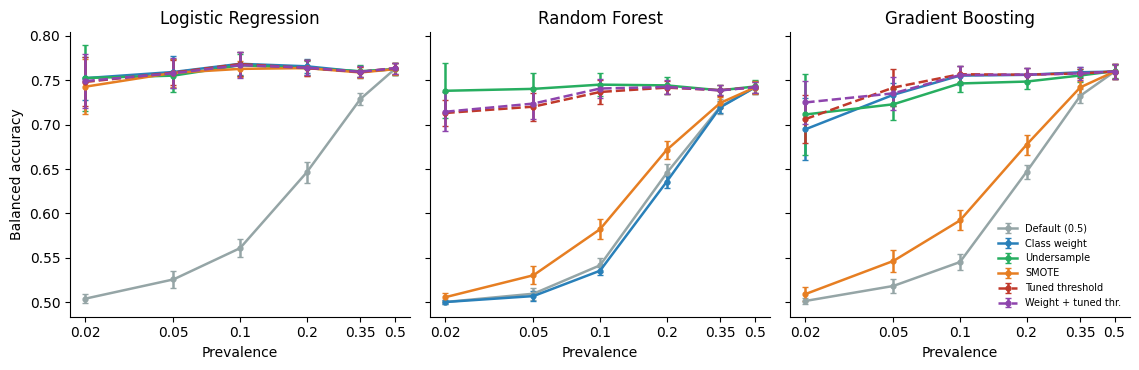

In [6]:
STRATS = ['default','weight','undersample','smote','threshold','weight+threshold']
COLORS = {'default':'#95a5a6','weight':'#2980b9','undersample':'#27ae60',
          'smote':'#e67e22','threshold':'#c0392b','weight+threshold':'#8e44ad'}
LABELS = {'default':'Default (0.5)','weight':'Class weight','undersample':'Undersample',
          'smote':'SMOTE','threshold':'Tuned threshold','weight+threshold':'Weight + tuned thr.'}
MODELS = {'logreg':'Logistic Regression','rf':'Random Forest','hgb':'Gradient Boosting'}
prevs = sorted(r.prevalence.unique())

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)
for ax, (mk, mname) in zip(axes, MODELS.items()):
    for s in STRATS:
        g = r[(r.model==mk)&(r.strategy==s)].groupby('prevalence')['balanced_acc']
        ax.errorbar(prevs, g.mean().values, yerr=g.std().values, label=LABELS[s],
                    color=COLORS[s], lw=1.8, marker='o', ms=3.5, capsize=2,
                    ls='--' if 'threshold' in s else '-')
    ax.set_title(mname); ax.set_xlabel('Prevalence')
    ax.set_xscale('log'); ax.set_xticks(prevs)
    ax.set_xticklabels([f'{p:g}' for p in prevs]); ax.minorticks_off()
    ax.spines[['top','right']].set_visible(False)
axes[0].set_ylabel('Balanced accuracy')
axes[2].legend(fontsize=7, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('figures/fig_balacc.png', dpi=300, bbox_inches='tight')
plt.show()

**Read the Random Forest panel.** The class-weight line (blue) lies on top of
the default line (grey) at every prevalence: per-tree balanced weighting does not
move a bagged majority-vote ensemble. SMOTE (orange) also fails for both tree
ensembles while matching class weighting for Logistic Regression. Undersampling
(green) and tuned thresholds (red, dashed) work everywhere.

In [7]:
print("Paired Wilcoxon across the 10 seeds, balanced accuracy:")
def paired(prev, model, a, b):
    x = r[(r.prevalence==prev)&(r.model==model)&(r.strategy==a)].sort_values('seed')['balanced_acc'].values
    y = r[(r.prevalence==prev)&(r.model==model)&(r.strategy==b)].sort_values('seed')['balanced_acc'].values
    stat, p = wilcoxon(x, y)
    print(f"  {model} @ prevalence {prev}: {a} ({x.mean():.3f}) vs {b} ({y.mean():.3f})  p = {p:.4f}")

paired(0.02, 'rf', 'weight', 'threshold')
paired(0.02, 'rf', 'smote', 'undersample')
paired(0.02, 'hgb', 'smote', 'weight')
paired(0.02, 'logreg', 'smote', 'weight')
paired(0.10, 'rf', 'weight', 'default')

Paired Wilcoxon across the 10 seeds, balanced accuracy:
  rf @ prevalence 0.02: weight (0.500) vs threshold (0.713)  p = 0.0020
  rf @ prevalence 0.02: smote (0.506) vs undersample (0.738)  p = 0.0020
  hgb @ prevalence 0.02: smote (0.509) vs weight (0.695)  p = 0.0020
  logreg @ prevalence 0.02: smote (0.743) vs weight (0.752)  p = 0.1055
  rf @ prevalence 0.1: weight (0.536) vs default (0.542)  p = 0.0137


The last test is worth pausing on: at 10% prevalence, class-weighted Random
Forest is *significantly worse than doing nothing* (p = 0.014). A widely
recommended default fix can be a small net negative for this model family.

A plausible mechanism for the SMOTE failures: after one-hot encoding, 33 of 37
features are binary indicators. SMOTE interpolates between minority neighbors,
producing fractional values on those indicators that no real record can have.
A linear model still shifts its decision function sensibly; axis-aligned tree
splits generalize poorly from them.

## 6. Result 3 — Threshold tuning works everywhere, and AUC explains why

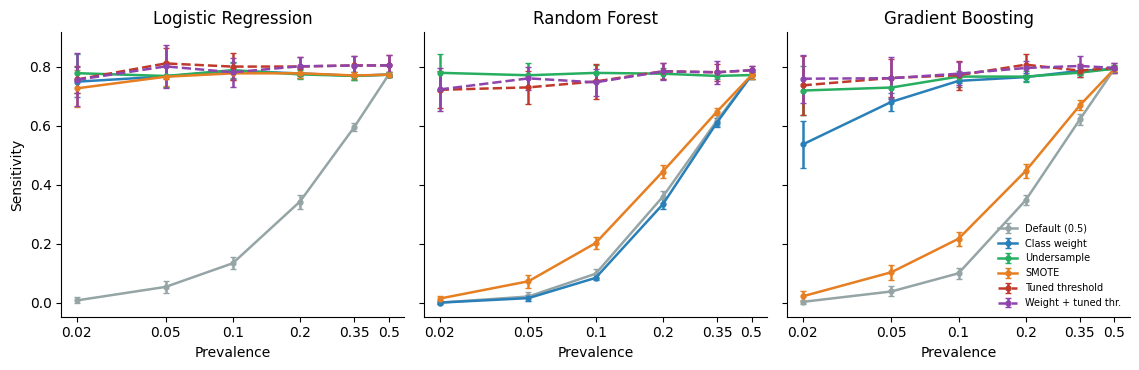

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)
for ax, (mk, mname) in zip(axes, MODELS.items()):
    for s in STRATS:
        g = r[(r.model==mk)&(r.strategy==s)].groupby('prevalence')['sensitivity']
        ax.errorbar(prevs, g.mean().values, yerr=g.std().values, label=LABELS[s],
                    color=COLORS[s], lw=1.8, marker='o', ms=3.5, capsize=2,
                    ls='--' if 'threshold' in s else '-')
    ax.set_title(mname); ax.set_xlabel('Prevalence')
    ax.set_xscale('log'); ax.set_xticks(prevs)
    ax.set_xticklabels([f'{p:g}' for p in prevs]); ax.minorticks_off()
    ax.spines[['top','right']].set_visible(False)
axes[0].set_ylabel('Sensitivity')
axes[2].legend(fontsize=7, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('figures/fig_sens.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print("ROC-AUC by training strategy (test set) - note how little it moves:")
for prev in [0.02, 0.10]:
    sub = r[r.prevalence==prev].pivot_table(index='model', columns='strategy',
                                            values='roc_auc', aggfunc='mean')
    print(f"prevalence {prev}:")
    print(sub[['default','weight','undersample','smote']].round(3).to_string())
    print()

ROC-AUC by training strategy (test set) - note how little it moves:
prevalence 0.02:
strategy  default  weight  undersample  smote
model                                        
hgb         0.788   0.794        0.781  0.783
logreg      0.824   0.823        0.814  0.813
rf          0.775   0.776        0.798  0.778

prevalence 0.1:
strategy  default  weight  undersample  smote
model                                        
hgb         0.833   0.831        0.817  0.821
logreg      0.842   0.842        0.839  0.838
rf          0.809   0.809        0.815  0.805



Training-time corrections leave ROC-AUC essentially unchanged (differences of
0.00-0.02). The models' learned *rankings* are fine even under severe imbalance;
what fails is the fixed 0.5 cutoff. That is why post-hoc threshold selection on a
validation split recovers full performance for every model at every prevalence,
with zero retraining.

## 7. Result 4 — The selected threshold tracks the prevalence

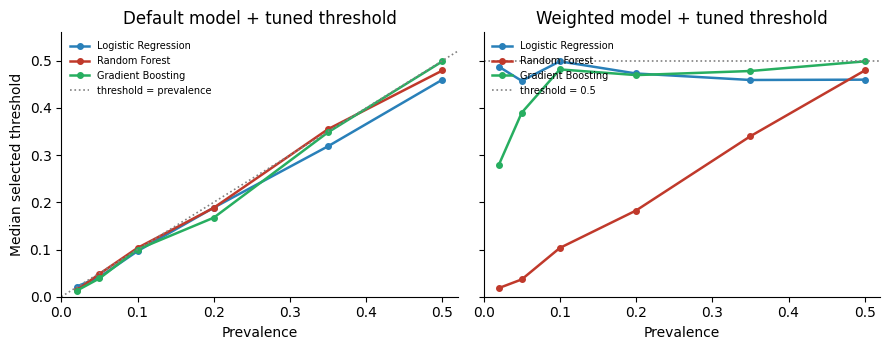

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
mcol = {'logreg':'#2980b9','rf':'#c0392b','hgb':'#27ae60'}
for ax, strat, title, ref in [
    (axes[0], 'threshold', 'Default model + tuned threshold', 'identity'),
    (axes[1], 'weight+threshold', 'Weighted model + tuned threshold', 'half')]:
    for mk, mname in MODELS.items():
        med = r[(r.model==mk)&(r.strategy==strat)].groupby('prevalence')['threshold'].median()
        ax.plot(prevs, med.values, marker='o', ms=4, lw=1.8, color=mcol[mk], label=mname)
    if ref == 'identity':
        ax.plot([0, 0.52], [0, 0.52], color='grey', ls=':', lw=1.2,
                label='threshold = prevalence')
    else:
        ax.axhline(0.5, color='grey', ls=':', lw=1.2, label='threshold = 0.5')
    ax.set_title(title); ax.set_xlabel('Prevalence')
    ax.set_xlim(0, 0.52); ax.set_ylim(0, 0.56)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=7, frameon=False, loc='upper left')
axes[0].set_ylabel('Median selected threshold')
plt.tight_layout()
plt.savefig('figures/fig_thresholds.png', dpi=300, bbox_inches='tight')
plt.show()

The validation-selected Youden threshold for default-trained models hugs the
identity line: **the right cutoff is approximately the prevalence itself**. After
effective class weighting (Logistic Regression, Gradient Boosting) the selected
threshold reverts to ~0.5, because weighting has already recalibrated the model to
a balanced prior. Random Forest's weighted threshold still tracks prevalence, one
more sign that weighting never changed its behavior.

## 8. General principles

1. **The imbalance problem here is an operating-point problem, not a representation
   problem.** ROC-AUC is nearly invariant to training-time corrections; a
   validation-tuned threshold alone recovers full balanced accuracy everywhere.
2. **Training-time corrections are mechanism-dependent.** Corrections that shift the
   effective class prior work where they enter the loss (weighting for Logistic
   Regression and Gradient Boosting) or the data itself (undersampling, all models).
   Per-class weighting fails for bagged majority-vote ensembles, and
   interpolation-based oversampling fails on predominantly one-hot features for
   tree models.
3. **Validation-based threshold selection is the only uniformly effective strategy**
   in this design, at zero retraining cost. Combining it with weighting adds
   essentially nothing.
4. **Selected thresholds approximately equal the prevalence** for default models,
   giving a practical rule of thumb, and revert to ~0.5 after effective reweighting.
5. **Corrections matter below ~20% prevalence and are immaterial at or above 35%**,
   where every strategy converges.

These principles are tested further in Sections 9 and 10: replication on two
additional datasets (which also directly tests the SMOTE mechanism in principle 2),
and the addition of focal loss as a fifth correction strategy.

### Limitations
One dataset size (N = 20,000), one threshold objective (Youden's J), three model
families in the main sweep. Calibration-based operating-point methods, cost-weighted
threshold objectives, and per-tree balanced Random Forest variants are not evaluated.
Prevalence is manipulated by subsampling, which changes the class mix but not the
within-class covariate distributions.

## 9. Replication on two additional datasets

Principle 2 above proposed a *mechanism* for SMOTE's failure: interpolation between
minority neighbors produces impossible fractional values on one-hot indicator
features, which tree models handle badly. That is a falsifiable prediction, SMOTE
should recover for tree models when continuous features dominate the feature space.

Two additional datasets test it, chosen to bracket the primary dataset in
continuous-feature share:

| Dataset | Records | Continuous / binary features |
|---|---|---|
| heart (primary) | 319,795 | 4 / 33 |
| diabetes (BRFSS 2015) | 253,680 | 7 / 14 |
| cardio (clinical exams) | 70,000 | 5 / 6 |

The identical protocol is applied at 2%, 10%, and 35% prevalence with 5 seeds each.
Run via `python experiment2.py cardio 0.02 0.10 0.35` (and `diabetes`).

In [11]:
ext = pd.read_csv("results/results_ext.csv")
print(f"{len(ext)} replication evaluations")
ext.pivot_table(index=['dataset','model','strategy'], columns='prevalence',
                values='balanced_acc', aggfunc='mean').round(3)

540 replication evaluations


prevalence                         0.02   0.10   0.35
dataset  model  strategy                             
cardio   hgb    default           0.500  0.513  0.718
                smote             0.529  0.632  0.722
                threshold         0.709  0.720  0.732
                undersample       0.692  0.712  0.727
                weight            0.711  0.720  0.729
                weight+threshold  0.699  0.722  0.732
         logreg default           0.500  0.530  0.695
                smote             0.736  0.724  0.725
                threshold         0.730  0.726  0.727
                undersample       0.734  0.724  0.727
                weight            0.738  0.725  0.726
                weight+threshold  0.733  0.726  0.725
         rf     default           0.500  0.536  0.708
                smote             0.515  0.622  0.708
                threshold         0.674  0.708  0.715
                undersample       0.712  0.711  0.712
                weight            0.500  0.533  0.706
                weight+threshold  0.680  0.702  0.713
diabetes hgb    default           0.500  0.533  0.722
                smote             0.503  0.565  0.728
                threshold         0.729  0.738  0.748
                undersample       0.723  0.730  0.744
                weight            0.695  0.745  0.747
                weight+threshold  0.745  0.746  0.748
         logreg default           0.500  0.536  0.707
                smote             0.746  0.741  0.743
                threshold         0.734  0.741  0.746
                undersample       0.741  0.742  0.743
                weight            0.753  0.741  0.743
                weight+threshold  0.742  0.739  0.747
         rf     default           0.500  0.525  0.713
                smote             0.502  0.588  0.720
                threshold         0.726  0.726  0.736
                undersample       0.756  0.737  0.738
                weight            0.500  0.520  0.713
                weight+threshold  0.731  0.728  0.737

**The headline findings replicate on both datasets:** default training fails at 2%
prevalence for every model (balanced accuracy 0.500), Random Forest class weighting
fails completely (0.500 on both, unchanged from default), and validation-tuned
thresholding works everywhere.

In [12]:
# The mechanism test: does SMOTE recover for tree models as continuous features dominate?
prim = pd.read_csv(RESULTS_PATH); prim['dataset'] = 'heart (primary)'
alld = pd.concat([prim[prim.prevalence.isin([0.02, 0.10, 0.35])], ext], ignore_index=True)

print("SMOTE vs default, tree models, at 10% prevalence:")
for ds, desc in [('heart (primary)','4 cont / 33 binary'),
                 ('diabetes','7 cont / 14 binary'),
                 ('cardio','5 cont / 6 binary')]:
    for m in ['rf','hgb']:
        sm = alld[(alld.dataset==ds)&(alld.model==m)&(alld.strategy=='smote')&(alld.prevalence==0.10)].balanced_acc.mean()
        df_ = alld[(alld.dataset==ds)&(alld.model==m)&(alld.strategy=='default')&(alld.prevalence==0.10)].balanced_acc.mean()
        print(f"  {ds:16s} ({desc:19s}) {m:4s}: SMOTE {sm:.3f}  default {df_:.3f}  gain {sm-df_:+.3f}")

SMOTE vs default, tree models, at 10% prevalence:
  heart (primary)  (4 cont / 33 binary ) rf  : SMOTE 0.582  default 0.542  gain +0.041
  heart (primary)  (4 cont / 33 binary ) hgb : SMOTE 0.592  default 0.545  gain +0.047
  diabetes         (7 cont / 14 binary ) rf  : SMOTE 0.588  default 0.525  gain +0.063
  diabetes         (7 cont / 14 binary ) hgb : SMOTE 0.565  default 0.533  gain +0.032
  cardio           (5 cont / 6 binary  ) rf  : SMOTE 0.622  default 0.536  gain +0.086
  cardio           (5 cont / 6 binary  ) hgb : SMOTE 0.632  default 0.513  gain +0.119


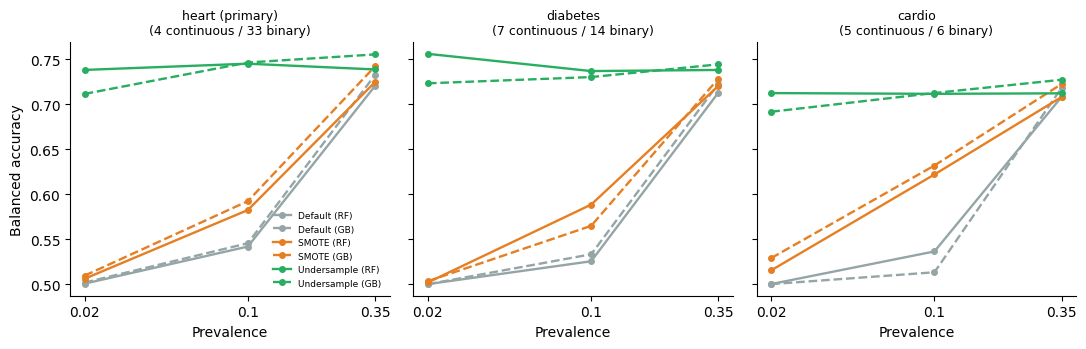

In [13]:
DS = [('heart (primary)','4 continuous / 33 binary'),
      ('diabetes','7 continuous / 14 binary'),
      ('cardio','5 continuous / 6 binary')]
prevs3 = [0.02, 0.10, 0.35]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, (ds, sub) in zip(axes, DS):
    for strat, col, lab in [('default','#95a5a6','Default'), ('smote','#e67e22','SMOTE'),
                            ('undersample','#27ae60','Undersample')]:
        for mk, ls, mm in [('rf','-','RF'), ('hgb','--','GB')]:
            g = alld[(alld.dataset==ds)&(alld.model==mk)&(alld.strategy==strat)].groupby('prevalence')['balanced_acc'].mean()
            ax.plot(prevs3, [g.get(p, np.nan) for p in prevs3], color=col, ls=ls,
                    lw=1.7, marker='o', ms=4, label=f'{lab} ({mm})')
    ax.set_title(f'{ds}\n({sub})', fontsize=9)
    ax.set_xlabel('Prevalence'); ax.set_xscale('log'); ax.set_xticks(prevs3)
    ax.set_xticklabels(['0.02','0.1','0.35']); ax.minorticks_off()
    ax.spines[['top','right']].set_visible(False)
axes[0].set_ylabel('Balanced accuracy')
axes[0].legend(fontsize=6.5, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('figures/fig_smote_datasets.png', dpi=300, bbox_inches='tight')
plt.show()

**Prediction confirmed.** SMOTE barely moves the tree models on the two
binary-dominant datasets, but on the continuous-dominant cardio dataset Random Forest
recovers from 0.536 (default) to 0.622. The failure is a property of the *feature
space*, not of SMOTE or of tree models in isolation. Practical rule: avoid SMOTE with
tree ensembles on one-hot-encoded categorical data; it is more defensible when
continuous features dominate.

## 10. Focal loss

Focal loss reshapes cross-entropy by a factor (1 - p_t)^gamma, down-weighting
well-classified examples so training concentrates on hard (typically minority) cases.
Two implementations, both gamma = 2 with an inverse-frequency class-balance term:

- **Logistic Regression:** focal objective minimized directly with L-BFGS using an
  analytic gradient (verified against finite differences, max error < 1e-5).
- **LightGBM:** custom objective supplying the analytic gradient and a
  finite-difference Hessian.

Run via `python experiment2.py gradcheck` and
`python experiment2.py focal 0.02 0.05 0.10 0.20 0.35 0.50`.

In [14]:
foc = pd.read_csv("results/results_focal.csv")
print(f"{len(foc)} focal-loss evaluations")
foc.pivot_table(index=['model','strategy'], columns='prevalence',
                values='balanced_acc', aggfunc='mean').round(3)

300 focal-loss evaluations


prevalence             0.02   0.05   0.10   0.20   0.35   0.50
model  strategy                                               
lgb    lgb_default    0.504  0.528  0.566  0.646  0.724  0.753
       lgb_focal      0.550  0.644  0.705  0.741  0.751  0.756
       lgb_threshold  0.682  0.723  0.743  0.749  0.753  0.754
       lgb_weight     0.545  0.634  0.704  0.738  0.751  0.753
logreg focal          0.751  0.760  0.768  0.765  0.759  0.762

In [15]:
# Focal vs the alternatives, paired across seeds
print("Focal LR vs class-weighted LR (primary dataset):")
for p in [0.02, 0.10]:
    f = foc[(foc.model=='logreg')&(foc.strategy=='focal')&(foc.prevalence==p)].sort_values('seed').balanced_acc.values
    w = r[(r.model=='logreg')&(r.strategy=='weight')&(r.prevalence==p)].sort_values('seed').balanced_acc.values
    print(f"  @{p}: focal {f.mean():.3f} vs weight {w.mean():.3f}  p = {wilcoxon(f, w)[1]:.3f}")

print("\nFocal LightGBM vs weighted LightGBM vs tuned threshold:")
for p in [0.02, 0.05, 0.10]:
    f = foc[(foc.strategy=='lgb_focal')&(foc.prevalence==p)].sort_values('seed').balanced_acc.values
    w = foc[(foc.strategy=='lgb_weight')&(foc.prevalence==p)].sort_values('seed').balanced_acc.values
    t = foc[(foc.strategy=='lgb_threshold')&(foc.prevalence==p)].balanced_acc.mean()
    print(f"  @{p}: focal {f.mean():.3f}  weight {w.mean():.3f} (p = {wilcoxon(f, w)[1]:.3f})  threshold {t:.3f}")

Focal LR vs class-weighted LR (primary dataset):
  @0.02: focal 0.751 vs weight 0.752  p = 1.000
  @0.1: focal 0.768 vs weight 0.768  p = 0.426

Focal LightGBM vs weighted LightGBM vs tuned threshold:
  @0.02: focal 0.550  weight 0.545 (p = 1.000)  threshold 0.682
  @0.05: focal 0.644  weight 0.634 (p = 0.010)  threshold 0.723
  @0.1: focal 0.705  weight 0.704 (p = 0.557)  threshold 0.743


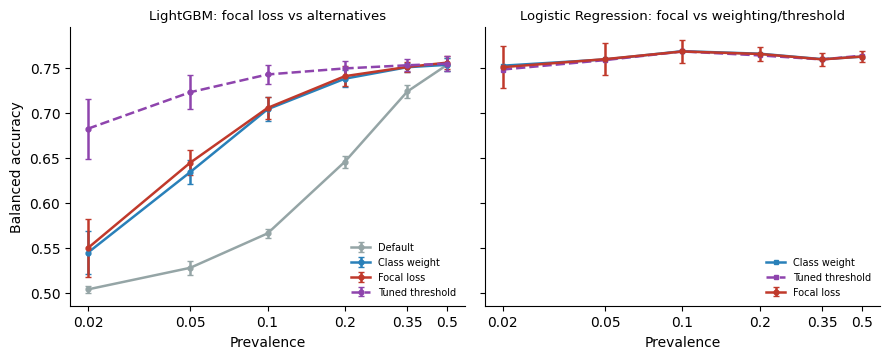

In [16]:
prevs6 = [0.02, 0.05, 0.10, 0.20, 0.35, 0.50]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.7), sharey=True)
for strat, col, lab in [('lgb_default','#95a5a6','Default'), ('lgb_weight','#2980b9','Class weight'),
                        ('lgb_focal','#c0392b','Focal loss'), ('lgb_threshold','#8e44ad','Tuned threshold')]:
    g = foc[foc.strategy==strat].groupby('prevalence')['balanced_acc'].agg(['mean','std'])
    axes[0].errorbar(prevs6, g['mean'].values, yerr=g['std'].values, color=col, lw=1.8,
                     marker='o', ms=3.5, capsize=2, label=lab,
                     ls='--' if strat=='lgb_threshold' else '-')
axes[0].set_title('LightGBM: focal loss vs alternatives', fontsize=9.5)
axes[0].set_ylabel('Balanced accuracy')

fl = foc[(foc.model=='logreg')&(foc.strategy=='focal')].groupby('prevalence')['balanced_acc'].agg(['mean','std'])
axes[1].errorbar(prevs6, fl['mean'].values, yerr=fl['std'].values, color='#c0392b',
                 lw=1.8, marker='o', ms=3.5, capsize=2, label='Focal loss')
for strat, col, lab in [('weight','#2980b9','Class weight'), ('threshold','#8e44ad','Tuned threshold')]:
    g = r[(r.model=='logreg')&(r.strategy==strat)].groupby('prevalence')['balanced_acc'].mean()
    axes[1].plot(prevs6, [g[p] for p in prevs6], color=col, lw=1.8, marker='s', ms=3.5,
                 ls='--' if strat=='threshold' else '-', label=lab)
axes[1].set_title('Logistic Regression: focal vs weighting/threshold', fontsize=9.5)
for ax in axes:
    ax.set_xlabel('Prevalence'); ax.set_xscale('log'); ax.set_xticks(prevs6)
    ax.set_xticklabels([f'{p:g}' for p in prevs6]); ax.minorticks_off()
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=7, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('figures/fig_focal.png', dpi=300, bbox_inches='tight')
plt.show()

**Focal loss is a competent member of the class-weighting family, not a superior
alternative.** For Logistic Regression it matches class weighting almost exactly
(0.751 vs 0.752 at 2% prevalence). For LightGBM it slightly beats class weighting at
low prevalence (0.644 vs 0.634 at 5%, p = 0.010), consistent with it being designed
for the hard-minority regime, but at every prevalence it stays below simply tuning
the threshold on the same model.

This *strengthens* the central conclusion: adding a fifth, more sophisticated
training-time correction still does not beat operating-point selection.